In [ ]:
import torch 
import sys 
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim


sys.path.insert(0, os.path.abspath('.'))

from src.data_loader import process_data_with_indicators, split_data
from envs.portfolio_env import PortfolioEnvWithBaselines
from agent.ppo import PPO

%load_ext autoreload
%autoreload 2

In [4]:
# Fetch data
tickers = [
    'AAPL',   # Apple Inc.
    'MSFT',   # Microsoft Corporation
    'GOOGL',  # Alphabet Inc. (Google)
    'AMZN',   # Amazon.com Inc.
    'NVDA',   # NVIDIA Corporation
    'META',   # Meta Platforms Inc. (Facebook)
    'TSLA',   # Tesla Inc.
    'NFLX',   # Netflix Inc.
    'UNH',    # UnitedHealth Group Inc.
    'JNJ',    # Johnson & Johnson
    'V',      # Visa Inc.
    'JPM',    # JPMorgan Chase & Co.
    'WMT',    # Walmart Inc.
    'MA',     # Mastercard Inc.
    'PG',     # Procter & Gamble Co.
    'HD',     # The Home Depot Inc.
    'DIS',    # The Walt Disney Company
    'BAC',    # Bank of America Corp.
    'XOM',    # Exxon Mobil Corporation
    'CVX'     # Chevron Corporation
]


In [5]:
# Get tickers data 
stock_data = {}
for ticker in tickers:
    df = pd.read_csv(f'data/{ticker}.csv', skiprows=2, index_col='Date', parse_dates=True)
    # Rename the first column to 'Date' if needed and set proper column names
    df.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    stock_data[ticker] = df

# Process data with indicators 
stock_data = process_data_with_indicators(stock_data)

# Split data into training, validation, and test sets 
training_data, validation_data, test_data = split_data(stock_data)


In [6]:
# Environment  
env = PortfolioEnvWithBaselines(training_data)

In [9]:
# Setting PPO agent 
agent = PPO(
    env=env,
    lr=2e-4, 
    gamma=0.99, 
    gae_lambda=0.95, 
    clip_range=0.2, 
    n_epochs=10, 
    batch_size=64, 
    ent_coef=0.01, 
    vf_coef=0.5
)

N_ITERATIONS = 50
STEPS_PER_EPOCH = 1600

training_stats = agent.train(n_iterations=N_ITERATIONS, 
                          steps_per_iter=STEPS_PER_EPOCH, 
                          )



Iteration 10/50 | Mean Reward: 0.09 | Policy Loss: -0.0157 | Value Loss: 0.0494 | Entropy: 30.6661
Iteration 20/50 | Mean Reward: 0.10 | Policy Loss: -0.0254 | Value Loss: 0.0310 | Entropy: 31.3023
Iteration 30/50 | Mean Reward: 0.10 | Policy Loss: -0.0232 | Value Loss: 0.0208 | Entropy: 32.0177
Iteration 40/50 | Mean Reward: 0.08 | Policy Loss: -0.0242 | Value Loss: 0.0316 | Entropy: 32.5489
Iteration 50/50 | Mean Reward: 0.10 | Policy Loss: -0.0225 | Value Loss: 0.0235 | Entropy: 32.9855


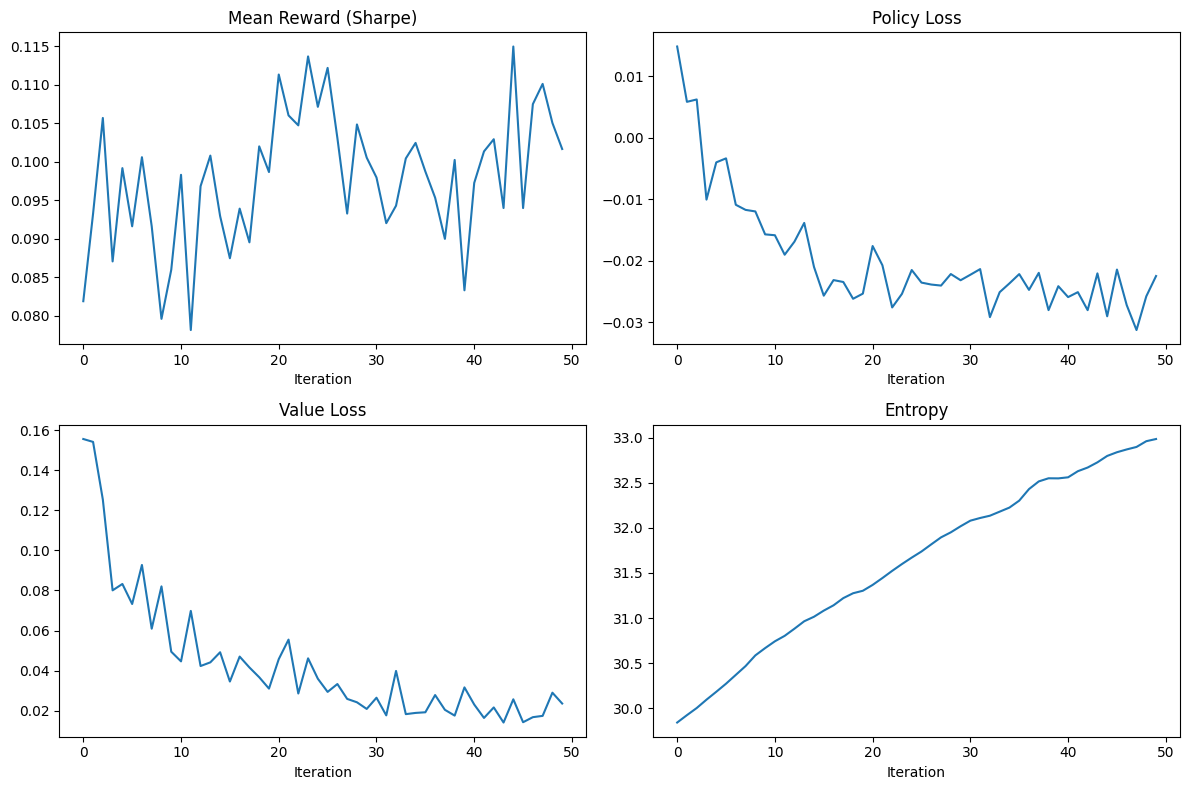

In [12]:
# Plot training stats 
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(training_stats['mean_rewards'])
axes[0, 0].set_title('Mean Reward (Sharpe)')
axes[0, 0].set_xlabel('Iteration')

axes[0, 1].plot(training_stats['policy_losses'])
axes[0, 1].set_title('Policy Loss')
axes[0, 1].set_xlabel('Iteration')

axes[1, 0].plot(training_stats['value_losses'])
axes[1, 0].set_title('Value Loss')
axes[1, 0].set_xlabel('Iteration')

axes[1, 1].plot(training_stats['entropies'])
axes[1, 1].set_title('Entropy')
axes[1, 1].set_xlabel('Iteration')

plt.tight_layout()
plt.show()

In [ ]:
# Backtest test data 
test_env = PortfolioEnvWithBaselines(test_data)
obs, info = test_env.reset() 

rl_values = [test_env.value]
baseline_values = {name: [test_env.initial_value] for name in test_env.baselines}

done = False
while not done: 
    action = agent.predict(obs) 
    obs, reward, terminated, truncated, info = test_env.step(action) 
    done = terminated or truncated 

    rl_values.append(info['portfolio_value']) 
    for name in test_env.baselines: 
        baseline_values[name].append(info.get(f'baseline_{name}', baseline_values[name][-1])) 



<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

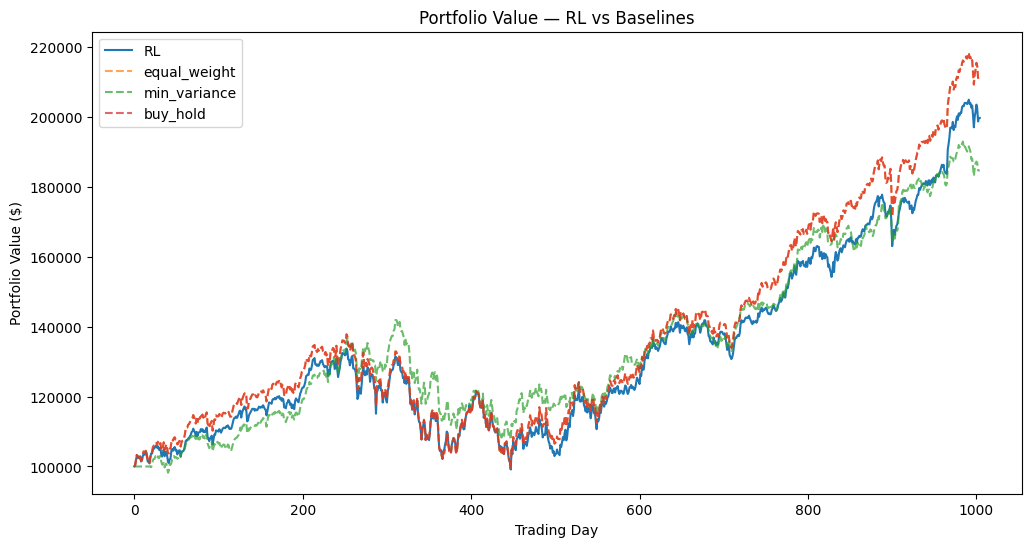

In [14]:
# Plot results 
plt.figure(figsize=(12, 6)) 

plt.plot(rl_values, label='RL') 
for name, vals in baseline_values.items(): 
    plt.plot(vals, label=name, linestyle='--', alpha=0.7) 

plt.title('Portfolio Value — RL vs Baselines') 
plt.xlabel('Trading Day') 
plt.ylabel('Portfolio Value ($)') 

plt.legend() 
plt.show() 


In [16]:
# Show final stats and metrics 
metrics = test_env.get_metrics() 
print(f"\nRL Agent Metrics")
print(f"  Total Return:  {metrics['total_return']:+.2f}%")
print(f"  Sharpe Ratio:  {metrics['sharpe_ratio']:.3f}")
print(f"  Max Drawdown:  {metrics['max_drawdown']:.2f}%")
print(f"  Final Value:   ${metrics['final_value']:,.2f}")


RL Agent Metrics
  Total Return:  +99.67%
  Sharpe Ratio:  1.134
  Max Drawdown:  25.87%
  Final Value:   $199,669.33


In [17]:
comparison = test_env.get_comparison()

print(f"{'Strategy':<16} {'Value':>12} {'Return':>10} {'Sharpe':>8}")
print('-' * 48)
for name, m in comparison.items():
    print(f"{name:<16} ${m['value']:>10,.2f} {m['return']:>+9.2f}% {m['sharpe']:>7.3f}")

Strategy                Value     Return   Sharpe
------------------------------------------------
RL Agent         $199,669.33    +99.67%   1.134
equal_weight     $211,818.36   +111.82%   1.136
min_variance     $184,621.36    +84.62%   1.205
buy_hold         $211,818.36   +111.82%   1.136
